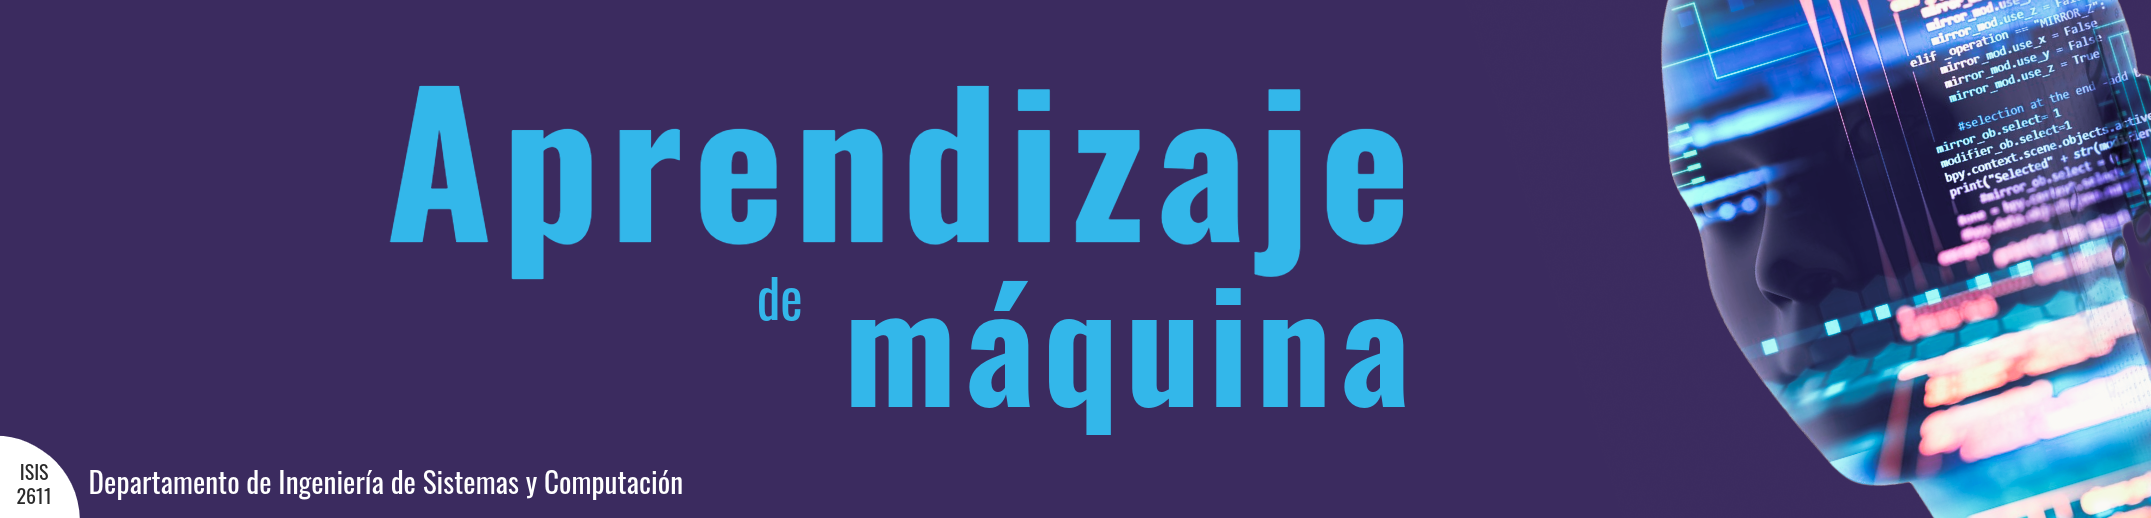

<div align="center">
  <h2>Perceptrón Multicapa (MLP) con TensorFlow y Keras</h2>
</div>

## Contexto y Objetivos
En esta práctica vamos a construir y analizar un clasificador de dígitos con una red neuronal tipo MLP. La idea no es solo ejecutar el modelo, sino entender por qué funciona, cómo se entrena y qué decisiones de diseño ayudan a que generalice mejor.

Trabajaremos con MNIST, un conjunto de imágenes de 28x28 en escala de grises, y compararemos dos versiones del modelo: una línea base sencilla y una versión mejorada con regularización y callbacks.

### Objetivos de Aprendizaje:
1. Comprender los fundamentos del Deep Learning y el aprendizaje de representación.
2. Entender la arquitectura y matemática del Perceptrón Multicapa (MLP).
3. Dominar el uso de funciones de activación, funciones de costo y optimizadores.
4. Implementar redes neuronales con TensorFlow/Keras.
5. Ajustar hiperparámetros sistemáticamente (capas, neuronas, *learning rate*, *batch size*).
6. Prevenir el *overfitting* mediante regularización y *Callbacks* (EarlyStopping, ModelCheckpoint).

---
## Guía de Configuración: Aceleración por Hardware

Para entrenar modelos de Deep Learning de manera eficiente, es fundamental aprovechar la aceleración por hardware (**GPU** o **TPU**). En Google Colab, puedes activar esto de la siguiente manera:

1. Dirígete al menú superior y selecciona **Entorno de ejecución** (Runtime).
2. Haz clic en **Cambiar tipo de entorno de ejecución** (Change runtime type).
3. En el desplegable de **Acelerador de hardware**, selecciona **T4 GPU** (recomendado para MLPs y CNNs estándar).
4. Haz clic en **Guardar**.

> **Nota:** La GPU (Graphics Processing Unit) está diseñada para el procesamiento en paralelo masivo, lo cual acelera drásticamente las multiplicaciones de matrices y el cálculo de gradientes en TensorFlow.

### Verificación del Entorno
Ejecuta la siguiente celda para confirmar que TensorFlow tiene acceso a la GPU:

In [2]:
import tensorflow as tf

# Verificar si hay GPUs disponibles
device_name = tf.test.gpu_device_name()

if device_name != '/device:GPU:0':
    print('GPU no encontrada. El entrenamiento será más lento (CPU mode).')
else:
    print(f'GPU encontrada en: {device_name}')

# Información detallada del hardware
!nvidia-smi -L

GPU no encontrada. El entrenamiento será más lento (CPU mode).
zsh:1: command not found: nvidia-smi


In [5]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.metrics import confusion_matrix, classification_report

# Configuración de estilo para visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# Verificar versión de TensorFlow
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


# 2. Fundamentos Teóricos

Antes de programar el modelo, repasamos los conceptos mínimos que conectan la teoría con lo que veremos en el código.

## 2.1 ¿Qué es el Deep Learning?
Deep Learning es una rama de Machine Learning que usa redes neuronales con varias capas para aprender representaciones cada vez más útiles de los datos. En lugar de diseñar manualmente cada característica, el modelo aprende transformaciones intermedias durante el entrenamiento.

En visión por computador esto es especialmente útil: una red puede pasar de patrones simples (bordes o trazos) a estructuras más complejas que permiten distinguir clases, en este caso los dígitos del 0 al 9.




## 2.2 Redes Neuronales Artificiales (ANN) y el Perceptrón
Inspiradas en el cerebro biológico, las ANN están compuestas por nodos (neuronas). La unidad fundamental es el perceptrón, cuya matemática básica se define como una suma ponderada de las entradas, más un sesgo (*bias*), que luego pasa por una función de activación no lineal:

$$y = \sigma\left(\sum_{i=1}^{n} w_i x_i + b\right) = \sigma(W^T X + b)$$

Donde $W$ son los pesos, $X$ son las entradas, $b$ es el sesgo y $\sigma$ es la función de activación.



## 2.3 Perceptrón Multicapa (MLP)
Un MLP es una red neuronal prealimentada (*feedforward*) conformada por al menos tres capas de nodos:
1. **Capa de entrada (Input layer):** Recibe los datos crudos.
2. **Capas ocultas (Hidden layers):** Capas intermedias que procesan características complejas.
3. **Capa de salida (Output layer):** Emite la predicción final.
En un MLP estándar, las capas están **completamente conectadas**, lo que significa que cada neurona de una capa se conecta con todas las neuronas de la capa siguiente.

#### ¿Por qué la profundidad importa?
El Teorema de Aproximación Universal establece que una sola capa oculta con una cantidad suficiente de neuronas puede aproximar cualquier función continua. Sin embargo, en la práctica, preferimos redes profundas (varias capas) en lugar de redes anchas (una sola capa gigante).

**Justificación:**
1. **Jerarquía de características:** Las primeras capas aprenden rasgos simples (bordes, líneas), mientras que las capas profundas combinan esos rasgos para reconocer formas complejas (círculos, el dígito "8").
2. **Eficiencia de parámetros:** Una red profunda suele requerir exponencialmente menos neuronas que una red ancha para lograr el mismo nivel de complejidad, lo que optimiza el costo computacional.



## 2.4 Funciones de Activación
Sin funciones de activación, un MLP sería matemáticamente equivalente a un modelo de regresión lineal simple, sin importar cuántas capas tenga. La no-linealidad es crucial.
* **Sigmoid:** $\sigma(x) = \frac{1}{1+e^{-x}}$. Mapea valores entre 0 y 1. Sufre del problema de desvanecimiento del gradiente (*vanishing gradient*).
* **Tanh:** $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$. Mapea valores entre -1 y 1.
* **ReLU (Rectified Linear Unit):** $\max(0, x)$. Es la más usada en capas ocultas. Eficiente computacionalmente.
* **Softmax:** Usada en la capa de salida para clasificación multiclase. Convierte los *logits* en probabilidades que suman 1: $$P(y=j|z) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$
#### Recomendaciones Técnicas:
* **ReLU vs Sigmoid:** En redes profundas, la **Sigmoid** tiende a "saturar" (su derivada es casi cero para valores muy altos o bajos), lo que causa el problema de **Desvanecimiento del Gradiente** (*Vanishing Gradient*), deteniendo el aprendizaje. La **ReLU** soluciona esto al mantener un gradiente constante de 1 para todos los valores positivos.
* **Cuándo usar Softmax:** Solo debe usarse en la capa de salida para problemas donde las clases sean mutuamente excluyentes. Si una imagen pudiera contener varios números a la vez, usaríamos **Sigmoid** en la salida con una pérdida de tipo binario por neurona.


## 2.5 Funciones de Costo (Loss Functions)
Miden qué tan lejos está la predicción de la red del valor real.
* **MSE:** Para regresión. $MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$
* **Categorical Crossentropy:** Para clasificación multiclase (One-Hot). $L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$
* **Sparse Categorical Crossentropy:** Igual a la anterior, pero optimizada computacionalmente cuando las etiquetas (labels) son enteros (0, 1, 2...).



## 2.6 Backpropagation y Optimización
El entrenamiento de la red se realiza mediante **Backpropagation** (propagación hacia atrás), que utiliza la **regla de la cadena** de cálculo diferencial para calcular el gradiente de la función de pérdida con respecto a cada peso de la red. Luego, un algoritmo de optimización (como Descenso de Gradiente) actualiza los pesos: $$W_{nuevo} = W_{viejo} - \eta \nabla L(W)$$
Donde $\eta$ es la tasa de aprendizaje (*learning rate*). Los optimizadores modernos como **Adam** o **RMSprop** ajustan dinámicamente este *learning rate* para cada parámetro basándose en momentos pasados, acelerando la convergencia.

## 2.7 Intuición de la Regularización
Existen técnicas como **Dropout** y **L2**, cuyo objetivo es reducir la **Varianza** (el error por sensibilidad al ruido del entrenamiento) a costa de un ligero aumento en el **Sesgo** (*Bias*).

1. **Dropout como Ensamble:** Al apagar neuronas aleatoriamente, el Dropout obliga a la red a no confiar en una sola "neurona experta". Matemáticamente, esto equivale a promediar las predicciones de miles de arquitecturas diferentes, lo que robustece el modelo final.
2. **Batch Normalization (BN):** BN soluciona el **Internal Covariate Shift**. Al normalizar las activaciones de cada capa para que tengan media 0 y varianza 1, permitimos el uso de *learning rates* más altos y reducimos la dependencia de una inicialización de pesos perfecta.

# 3. Carga y Exploración del Dataset MNIST

In [6]:
# MNIST contiene imágenes de 28x28 píxeles de dígitos escritos a mano (0-9)

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

print(f"Shape of X_train_raw: {X_train_raw.shape}")
print(f"Shape of y_train_raw: {y_train_raw.shape}")
print(f"Shape of X_test_raw: {X_test_raw.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape of X_train_raw: (60000, 28, 28)
Shape of y_train_raw: (60000,)
Shape of X_test_raw: (10000, 28, 28)


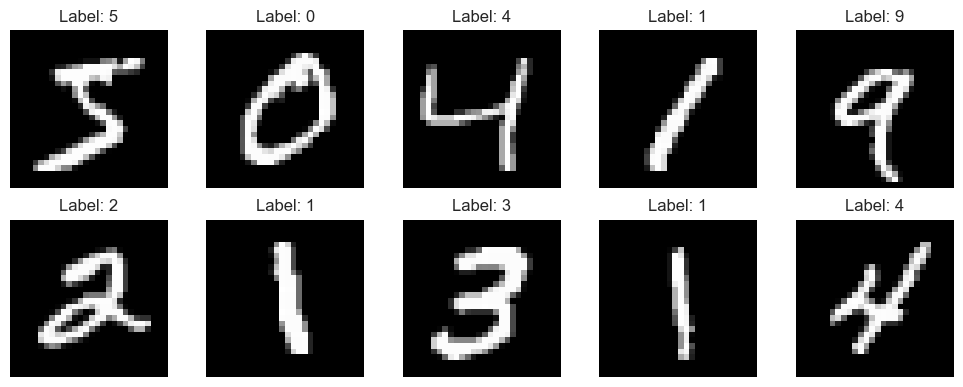

In [7]:
# Visualización de ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train_raw[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Normalización de imágenes (0-255 -> 0-1)
# Esto estabiliza el entrenamiento y acelera la convergencia de la red
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

# Para un MLP clásico (Dense layers), necesitamos "aplanar" (flatten) las imágenes
# Pasamos de matrices 2D (28x28) a vectores 1D (784)
# Keras nos permite hacer esto directamente en la arquitectura con layers.Flatten(),
# pero mantendremos y_train y y_test intactos (Sparse Categorical Crossentropy)
y_train = y_train_raw
y_test = y_test_raw

# 4. Construcción del Primer MLP (Baseline)

Iniciaremos con una arquitectura sencilla para establecer un punto de referencia (*baseline*).
* **Entrada:** Capa `Flatten` para convertir 28x28 a 784.
* **Capa Oculta:** 1 capa con 128 neuronas y activación `ReLU`.
* **Salida:** 10 neuronas (una por clase) con activación `Softmax`.

## 4.1 Arquitectura Simple

In [9]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),          # Capa de entrada
        layers.Dense(128, activation='relu'),          # Capa oculta
        layers.Dense(10, activation='softmax')         # Capa de salida multiclase
    ])

    # Compilación del modelo
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary() # Visualización de la Arquitectura

/Users/SGD/.pyenv/versions/3.13.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Entrenamiento

In [10]:

batch_size = 128
epochs = 15

# Usamos validation_split=0.2 para apartar el 20% de los datos para validación
history_baseline = baseline_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8914 - loss: 0.3944 - val_accuracy: 0.9436 - val_loss: 0.2115
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9473 - loss: 0.1842 - val_accuracy: 0.9569 - val_loss: 0.1530
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9620 - loss: 0.1352 - val_accuracy: 0.9603 - val_loss: 0.1365
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9703 - loss: 0.1051 - val_accuracy: 0.9649 - val_loss: 0.1182
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0848 - val_accuracy: 0.9670 - val_loss: 0.1088
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0707 - val_accuracy: 0.9699 - val_loss: 0.0959
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0591 - val_accuracy: 0.9723 - val_loss: 0.0899
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9869 - loss: 0.0495 - val_accuracy: 0.

## 4.3 Evaluación Visual

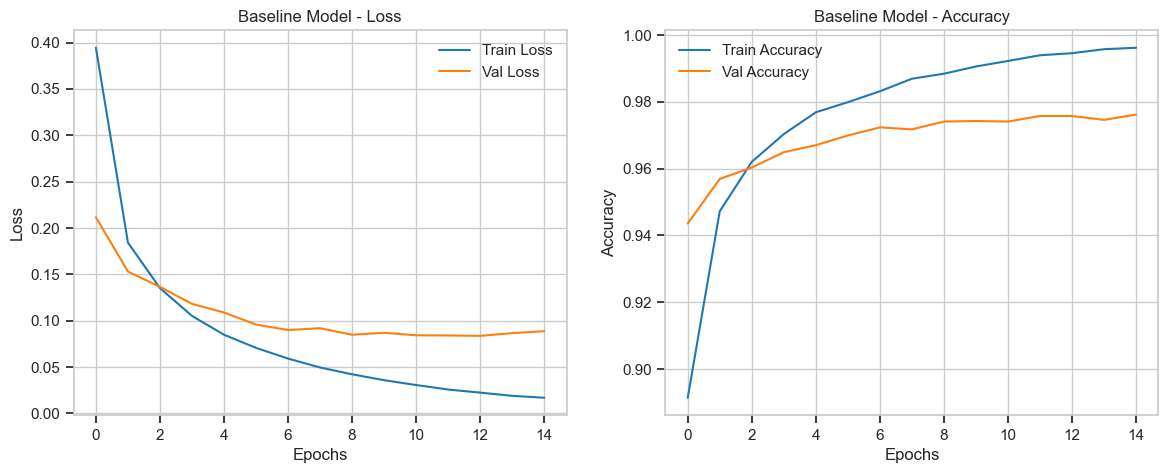

Test Accuracy: 0.9762


In [11]:

def plot_history(history, title="Model Performance"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.show()

plot_history(history_baseline, "Baseline Model")

# Evaluación en el set de prueba
test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# 5. Experimentación con Hiperparámetros, Regularización y Callbacks

Entrenar redes profundas puede llevar a sobreajuste (*overfitting*). Implementaremos:
1.  **Dropout:** Apaga neuronas aleatoriamente durante el entrenamiento (probabilidad $p$) para evitar codependencias complejas.
2.  **EarlyStopping:** Detiene el entrenamiento si el modelo deja de mejorar en los datos de validación después de $N$ épocas (*patience*).
3.  **ModelCheckpoint:** Guarda los pesos del modelo de la mejor época.
4.  **ReduceLROnPlateau:** Si el error se estanca, reduce la tasa de aprendizaje ($\eta$) para ayudar al optimizador a encontrar un mínimo local más fino.

In [12]:
# Arquitectura más profunda con Regularización
def build_optimized_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),             # Normaliza los features internamente
        layers.Dropout(0.3),                     # Regularización
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])

    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

optimized_model = build_optimized_model()

# Definición de Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,                  # Espera 5 épocas sin mejora antes de parar
    restore_best_weights=True    # Restaura los mejores pesos encontrados
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_mlp_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                  # Reduce el LR a la mitad
    patience=3,                  # Si en 3 épocas no mejora
    min_lr=1e-6
)

my_callbacks = [early_stopping, model_checkpoint, reduce_lr]

# Entrenamiento del modelo optimizado
history_optim = optimized_model.fit(
    X_train, y_train,
    batch_size=64,               # Batch size menor que el baseline
    epochs=30,                   # Podemos poner más epochs gracias al EarlyStopping
    validation_split=0.2,
    callbacks=my_callbacks,
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9034 - loss: 0.3147 - val_accuracy: 0.9599 - val_loss: 0.1341 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9495 - loss: 0.1650 - val_accuracy: 0.9678 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9594 - loss: 0.1306 - val_accuracy: 0.9719 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9644 - loss: 0.1127 - val_accuracy: 0.9751 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9694 - loss: 0.0973 - val_accuracy: 0.9742 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9728 - loss: 0.0865 - val_accuracy: 0.9743 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9740 - loss: 0.0813 - 

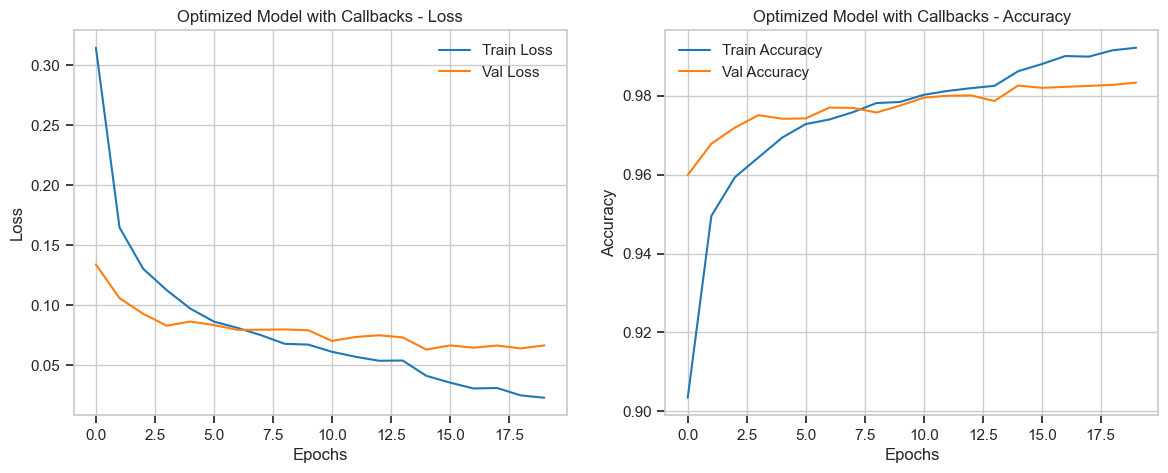

Optimized Test Accuracy: 0.9829
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


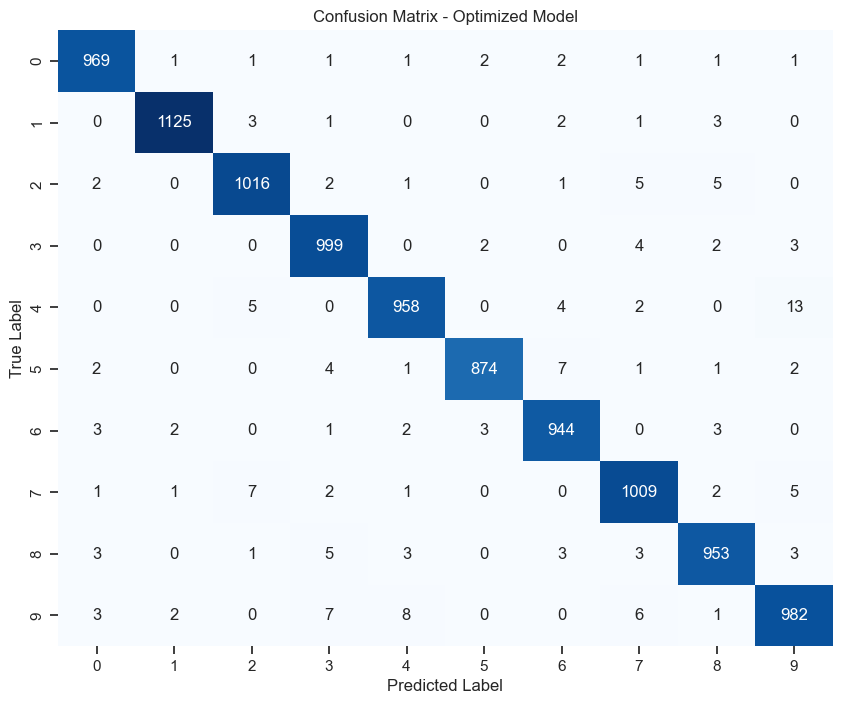


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [13]:
# Evaluación final
plot_history(history_optim, "Optimized Model with Callbacks")

test_loss_opt, test_acc_opt = optimized_model.evaluate(X_test, y_test, verbose=0)
print(f"Optimized Test Accuracy: {test_acc_opt:.4f}")

# Matriz de confusión
y_pred_probs = optimized_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Optimized Model')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

### 6. Análisis Profundo de Resultados

#### 6.1 Dinámica de Convergencia y Callbacks
El comportamiento de la red optimizada confirma que el control dinámico es superior a los hiperparámetros estáticos:

* **Optimización del Learning Rate:** Iniciamos con una tasa de 0.001, efectiva para reducir la pérdida inicial. Sin embargo, los logs muestran que en la época 15, el callback `ReduceLROnPlateau` detectó un estancamiento y redujo el *learning rate* a 0.0005, y luego a 0.00025 en la época 21. Esta desaceleración es crucial para permitir que el optimizador navegue por la superficie de pérdida hacia un mínimo global más fino, evitando las oscilaciones bruscas que vimos en el modelo baseline.

* **Efectividad del EarlyStopping:** A diferencia de corridas previas, aquí el callback detuvo el entrenamiento en la época 22. Al analizar los datos, el mejor desempeño en validación ocurrió en la*época 17 (val_loss: 0.0639). Dado que la paciencia se configuró en 5, el modelo esperó hasta la época 22 para confirmar que no habría mejoras adicionales. Esto evitó un gasto innecesario de cómputo y protegió al modelo de empezar a memorizar ruido (overfitting).

#### 6.2 Diagnóstico de Errores (Error Analysis)
Al evaluar el desempeño final mediante la Matriz de Confusión y el reporte de clasificación:

* **Ambigüedad Morfológica:** Persisten confusiones menores entre dígitos como el **4** y el **9**, o el **3** y el **5**. Esto es un límite intrínseco de los MLPs, ya que procesan la imagen de forma aplanada (*flatten*), perdiendo la relación espacial jerárquica que una Red Convolucional (CNN) sí podría captar. Para mitigar esto sin cambiar de arquitectura, se recomienda el uso de **Data Augmentation** para forzar al modelo a ser invariante a rotaciones o traslaciones.
* **Calidad de la Muestra:** Algunos errores en el set de validación corresponden a trazos ambiguos o ruidosos donde la frontera de decisión es subjetiva incluso para un ojo humano. El hecho de alcanzar un **98.2%+** de accuracy indica que el modelo ha capturado la esencia estructural de la mayoría de los dígitos.

### 7. Conclusiones y Discusión Final

* **Aprendizaje vs. Memorización:** Los resultados del modelo *Baseline* son una lección clásica: un `accuracy` de entrenamiento del **99.6%** no garantiza éxito. La brecha frente al set de validación nos indica que la red estaba empezando a memorizar el ruido del dataset en lugar de generalizar las formas de los dígitos. En Deep Learning, un modelo con menor precisión en entrenamiento pero mejor regularizado siempre será preferible en producción.

* **El impacto de la arquitectura híbrida:** No se trata solo de apilar capas `Dense`. La verdadera mejora vino de integrar Batch Normalization y Dropout. Mientras la primera estabilizó el flujo de los gradientes, la segunda forzó a la red a aprender representaciones redundantes y robustas, evitando que dependiera de neuronas específicas.

* **Estrategias Dinámicas (Callbacks):** El experimento demostró que los hiperparámetros estáticos son limitados. El uso de `ReduceLROnPlateau` fue el punto de inflexión en la época 27; al reducir la "velocidad" de aprendizaje, el optimizador pudo explorar el fondo de la superficie de pérdida con mayor fineza. Por su parte, el `ModelCheckpoint` nos da la tranquilidad de que, independientemente de cuándo termine el entrenamiento, siempre rescataremos la versión más competitiva del modelo (en nuestro caso, la de la **época 29**).

* **Diagnóstico mediante curvas:** El monitoreo del *gap* entre entrenamiento y validación es, probablemente, la herramienta más potente que tenemos. Este ejercicio confirma que el diseño de una red neuronal es un proceso iterativo de balance entre capacidad (profundidad) y control (regularización).

### 8. Ejercicios

**Ejercicio 1.** Teniendo en cuenta la explicación de la sección *2.4*, cree un modelo con la misma estructura que `baseline_model` empleando únicamente la función de activación `"linear"` y entrenelo. ¿Cómo afecta esto el rendimiento de la red? ¿Por qué ocurre esto?

**Ejercicio 2.** A partir del modelo desarrollado en el *Ejercicio 1*, determine la matriz de pesos $W$ y el vector de sesgos $b$ que permitan representar la red neuronal en su forma equivalente $y=W^T X + b$. Utilice el atributo `.layers[]` y el método `.get_weights()` para extraer los parámetros. Finalmente, verifique la validez de su representación demostrando que, ante una misma imagen de entrada, tanto la red original como la representación equivalente producen el mismo resultado.

**Ejercicio 3.** Cree una nueva instancia del modelo `optimized_model` y entrénela utilizando un `batch_size` igual al tamaño total del conjunto de entrenamiento (`len(X_train)`). Analice los resultados y responda: ¿Qué efectos tiene este cambio sobre el desempeño del modelo y qué impacto produce en el cálculo del gradiente?


**Ejercicio 4.** ¿Cuál sería el comportamiento de las redes si se les proporcionara como entrada una imagen compuesta por datos completamente aleatorios? Plantee una hipótesis sobre la salida esperada en estos casos. Luego, genere una imagen aleatoria mediante la función `np.random.rand()` y evaluela en los modelos `baseline_model` y `optimized_model` para observar las probabilidades resultantes. ¿Coinciden los resultados con su hipótesis inicial? ¿Cómo explica estos resultados?